In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import copy

In [2]:
from skimage.io import imread
from skimage.io import imsave
from skimage import filters
from skimage import morphology
from skimage import measure

In [3]:
#from scipy import ndimage as ndi
from skimage import (exposure, feature, filters, io, measure,
                      morphology, restoration, segmentation, transform,
                      util)

In [4]:
import napari
from napari.utils import nbscreenshot

In [5]:
from pyclesperanto_prototype import imshow
import pyclesperanto_prototype as cle
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

In [6]:
cle.available_device_names()
# For 3D processing, powerful graphics
# processing units might be necessary
cle.select_device('TX')

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/pyclesperanto_prototype/_tier0/_device.py:77: UserWarning: No OpenCL device found with TX in their name. Using Apple M1 Max instead.
  warnings.warn(f"No OpenCL device found with {name} in their name. Using {device.name} instead.")


<Apple M1 Max on Platform: Apple (2 refs)>

In [7]:
#import czifile
from aicsimageio import AICSImage
from aicsimageio.writers import OmeTiffWriter

In [8]:
inputDir = "/Volumes/groups/tanaka/Collaborations/Jingkui-Lu/development"
#fileName = '2d-Right2-Stitching.czi'
#fileName = "Right4-Stitching.czi"
fileName = "3d-Right4-Stitching.czi"

path_results = 'results/' \
        + 'test_3D_erosion' + '/'
outDir = path_results

if not os.path.exists(outDir):
    os.makedirs(outDir)

print(outDir)

results/test_3D_erosion/


In [9]:
## read czi file (original code https://biapol.github.io/Image-data-science-with-Python-and-Napari-EPFL2022/day2b_Working_with_Images/04_Image_file_formats.html)
#img = czifile.imread(os.path.join(inputDir, fileName))
#img.shape
#czi_dimstring = img.axes
# shape will give you the dimensions of the array
#czi_shapeinfo = img.shape

In [10]:
## read czi file (https://forum.image.sc/t/reading-czi-file-in-python/39768/3)
img = AICSImage(os.path.join(inputDir, fileName))

In [11]:
image = img.data #returns 6D STCZYX numpy array

In [12]:
print(image.shape)
print(img.dims)  # returns string "STCZYX"
print(img.shape)  # returns tuple of dimension sizes in STCZYX order

(1, 2, 110, 1948, 2861)
<Dimensions [T: 1, C: 2, Z: 110, Y: 1948, X: 2861]>
(1, 2, 110, 1948, 2861)


In [13]:
# Metadata Reading (https://allencellmodeling.github.io/aicsimageio/index.html)
img.channel_names  # returns a list of string channel names found in the metadata

[np.str_('DAPI-T1'), np.str_('AF488-T2')]

In [14]:
print(img.physical_pixel_sizes.Z)  # returns the Z dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.Y)  # returns the Y dimension pixel size as found in the metadata
print(img.physical_pixel_sizes.X)  # returns the X dimension pixel size as found in the metadata

2.0
0.828642578125
0.828642578125


In [15]:
dapi_c1 = img.get_image_data("ZYX", C=0, S=0, T=0)
neuron_c2 = img.get_image_data("ZYX", C=1, S=0, T=0)

In [16]:
print(dapi_c1.shape) 
print(neuron_c2.shape)

(110, 1948, 2861)
(110, 1948, 2861)


In [17]:
np.max(dapi_c1)

np.uint16(32997)

In [18]:
#https://www.dropbox.com/scl/fi/tzy1dsrgtxx3u53pltmbx/2d-Right2-Stitching_C1_dapi.tif?rlkey=9eiev2rac3c4ez0dmorw45w6r&st=1hs7bkbp&dl=0

In [19]:
#viewer = napari.Viewer()
#viewer.add_image(dapi_c1)
#viewer.add_image(neuron_c2)
#nbscreenshot(viewer)

In [20]:
fileName.removesuffix('.czi')

'3d-Right4-Stitching'

In [21]:
print(neuron_c2.shape)
print(dapi_c1.shape)

(110, 1948, 2861)
(110, 1948, 2861)


In [22]:
neuron_downsample = transform.downscale_local_mean(neuron_c2, factors=(1, 2, 2))
dapi_downsample = transform.downscale_local_mean(dapi_c1, factors=(1, 2, 2))

In [23]:
print(neuron_downsample.shape)
print(dapi_downsample.shape)

(110, 974, 1431)
(110, 974, 1431)


In [24]:
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_dapi.tif")), dapi_c1)
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_dapi_downsampled_v2.tif")), dapi_downsample)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C2_neuron.tif")), neuron_c2)
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C2_neuron_downsampled_v2.tif")), neuron_downsample)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_" + str(nb_inter_erosion) + ".tif")), dapi_new)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C2_" + str(nb_inter_erosion) + ".tif")), neron_new)

In [25]:
print(outDir)

results/test_3D_erosion/


In [21]:
#img.get_physical_pixel_size()
#image_squeezed = np.squeeze(image)
#image_squeezed.shape

In [22]:
#viewer = napari.Viewer()
#viewer.add_image(image_squeezed)
#nbscreenshot(viewer)

In [23]:
#with napari.gui_qt():
#    viewer = napari.Viewer()  # how do I use napari-aicsimageio instead?
#    layer = viewer.add_image(img.data)

In [39]:
#denoised = ndi.gaussian_filter(dapi_c1, sigma = 3) # sigma is one parameter to tune
denoised = cle.gaussian_blur(dapi_c1, sigma_x=2, sigma_y= 2, sigma_z=2) # sigma is one parameter to tune

In [40]:
binary = cle.threshold_otsu(denoised)

In [41]:
binary = cle.closing_sphere(binary, radius_x=2, radius_y= 2, radius_z=2)

In [42]:
viewer.add_image(binary, name='gaussianBlur_thresholdedOsu')

<Image layer 'gaussianBlur_thresholdedOsu' at 0x3a633e310>

In [44]:
labels = cle.connected_components_labeling_box(binary)
background = cle.binary_not(labels)

In [48]:
np.max(labels), np.max(background), np.max(binary)

(np.float32(655.0), np.float32(1.0), np.float32(1.0))

In [45]:
viewer.add_image(background, name='gaussianBlur_thresholdedOsu_background')

<Image layer 'gaussianBlur_thresholdedOsu_background' at 0x3a7078910>

In [49]:
voronoi_filled = cle.voronoi_labeling(background)

In [51]:
filled_labels = cle.combine_labels(labels, voronoi_filled)

In [52]:
viewer.add_image(filled_labels, name='filled_labels')

<Image layer 'filled_labels' at 0x3a1abe610>

In [22]:
## test different thresholding
thresholded_li = dapi_c1 > filters.threshold_li(dapi_c1)
viewer.add_image(thresholded_li, name='thresholded_li')

<Image layer 'thresholded_li' at 0x3cb0a69d0>

In [28]:
#thresholded_minimum = dapi_c1 > filters.threshold_minimum(dapi_c1)
#viewer.add_image(thresholded_minimum, name='thresholded_minimum')

In [24]:
thresholded_mean = dapi_c1 > filters.threshold_mean(dapi_c1)
viewer.add_image(thresholded_mean, name='thresholded_mean')

<Image layer 'thresholded_mean' at 0x4165a3ac0>

In [25]:
### try to segment the limb using dapi channel (https://scikit-image.org/skimage-tutorials/lectures/three_dimensional_image_processing.html)
denoised = ndi.gaussian_filter(dapi_c1, sigma = 3) # sigma is one parameter to tune

In [26]:
denoised_thresholded_li = dapi_c1 > filters.threshold_li(denoised)
viewer.add_image(denoised_thresholded_li, name='denoised_thresholded_li')

<Image layer 'denoised_thresholded_li' at 0x4165f3910>

In [27]:
denoised_thresholded_mean = dapi_c1 > filters.threshold_mean(denoised)
viewer.add_image(denoised_thresholded_mean, name='denoised_thresholded_mean')

<Image layer 'denoised_thresholded_mean' at 0x416642040>

In [45]:
#thresholded = denoised > filters.threshold_otsu(denoised)
#thresholded = dapi_c1 > filters.threshold_otsu(denoised)
#thresholded = denoised > filters.threshold_otsu(denoised)
import pyclesperanto_prototype as cle
segmented = cle.voronoi_otsu_labeling(dapi_c1, spot_sigma=10, outline_sigma=4)
#show(segmented, labels=True)

In [46]:
labels_mask, nb_objects = measure.label(segmented, return_num = True)

In [47]:
labels_mask_binary = labels_mask > 0
viewer.add_image(labels_mask_binary, name='labels_mask_binary')

<Image layer 'labels_mask_binary [1]' at 0x602380280>

In [50]:
filled_holes = ndi.binary_fill_holes(labels_mask_binary, structure=np.ones((10, 10, 4))).astype(int)

In [51]:
viewer.add_image(filled_holes, name='filled_holes')

<Image layer 'filled_holes [1]' at 0x3aef95130>

In [21]:
thresholded = denoised > filters.threshold_li(denoised)

In [22]:
viewer.add_image(thresholded, name='thresholded_li')

<Image layer 'thresholded_li' at 0x3c24417f0>

/Users/jingkui.wang/miniforge3/envs/image_env/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (110, 1948, 2861) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


In [32]:
np.max(thresholded), np.min(thresholded), np.sum(thresholded)

(True, False, 608399724)

In [42]:
nb_inter_erosion = 27 # nb of interation for erosion 
erosion = ndi.binary_erosion(thresholded, iterations=nb_inter_erosion, border_value=0)

In [43]:
viewer.add_image(erosion, name='erosion')

<Image layer 'erosion [3]' at 0x61661b550>

In [31]:
np.max(dapi_c1)

32997

In [45]:
dapi_new = copy.deepcopy(dapi_c1)
neron_new = copy.deepcopy(neuron_c2)

In [46]:
np.max(dapi_c1), np.max(dapi_new)

(40344, 40344)

In [47]:
mask_invert = np.invert(erosion)

In [48]:
dapi_new[mask_invert] = 0
neron_new[mask_invert] = 0

In [49]:
dapi_new.shape

(180, 2876, 5624)

In [50]:
viewer.add_image(dapi_new, name='dapi_new')
viewer.add_image(neron_new, name='neron_new')

<Image layer 'neron_new' at 0x85101bc10>

In [51]:
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_" + str(nb_inter_erosion) + ".tif")), dapi_new)
imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C2_" + str(nb_inter_erosion) + ".tif")), neron_new)

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_89846/1714544306.py:2: UserWarning: results/test_3D_erosion/Right4-Stitching_C2_27.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C2_" + str(nb_inter_erosion) + ".tif")), neron_new)


In [75]:
np.max(thresholded), np.min(thresholded), np.sum(thresholded)

(True, False, 149840182)

In [30]:
np.max(erosion), np.min(erosion),np.sum(erosion)

NameError: name 'erosion' is not defined

In [22]:
#### test mesh surface approach
#from vedo import *

In [23]:
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_DAPI_C1.tif")), dapi_c1)

In [24]:
#vol_dapi = load(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_DAPI_C1.tif")))

In [25]:
#vol_dapi.show()

In [19]:
fileName

'3d-Right4-Stitching.czi'

2025-06-16 15:58:01.923 python[45317:24298619] +[IMKClient subclass]: chose IMKClient_Modern
2025-06-16 15:58:01.923 python[45317:24298619] +[IMKInputSession subclass]: chose IMKInputSession_Modern


In [ ]:
#######################
##### test different way to make mesh surface 
##### segment first and fill holes
##### flood fill and find the tissue border
#######################

In [ ]:
import pyclesperanto_prototype as cle
segmented = cle.voronoi_otsu_labeling(dapi_c1, spot_sigma=3, outline_sigma=1)
#show(segmented, labels=True)

In [53]:
labels_mask, nb_objects = measure.label(segmented, return_num = True)
viewer.add_image(labels_mask, name='labels_mask_3D')

In [54]:
viewer.add_image(labels_mask, name='labels_mask_3D')

<Image layer 'labels_mask_3D' at 0x6d04de2e0>

In [55]:
labels_mask.shape

(110, 1948, 2861)

In [69]:
labels_mask[109, :, :] = 0
labels_mask[108, :, :] = 0
labels_mask[107, :, :] = 0

In [70]:
viewer.add_image(labels_mask, name='labels_mask_3D_zeroBorder')

<Image layer 'labels_mask_3D_zeroBorder' at 0x6d077d790>

In [71]:
labels_mask_binary = labels_mask > 0

In [ ]:
filled_holes = ndi.binary_fill_holes(labels_mask_binary, structure=np.ones((10, 10, 4))).astype(int)

In [ ]:
viewer.add_image(filled_holes, name='filled_holes')

In [ ]:
ndimage.binary_fill_holes(bw_fill)

In [19]:
dapi_new = imread(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1.tif")))
#dapi_new = imread(os.path.join(outDir, "Right4-Stitching_C1_27.tif"))

In [20]:
#from vedo import Volume, dataurl
#vol = Volume(dataurl+'embryo.tif')
#vol.append(vol).show()

In [21]:
dapi_new.shape

(110, 1948, 2861)

In [22]:
denoised = ndi.gaussian_filter(dapi_new, sigma = 10) # sigma is one parameter to tune

In [23]:
thresholded_2 = denoised > filters.threshold_li(denoised)

In [24]:
viewer.add_image(thresholded_2, name='thresholded_2')

<Image layer 'thresholded_2' at 0x3c636cfa0>

In [26]:
import mcubes

#verts, faces, _, _ = measure.marching_cubes(dapi_c1, 0.0)
#verts, faces, normals, values = measure.marching_cubes(thresholded, 0.9)
smoothed_sphere = mcubes.smooth(thresholded_2)

# Extract the 0-levelset (the 0-levelset of the output of mcubes.smooth is the
# smoothed version of the 0.5-levelset of the binary array).
verts, faces = mcubes.marching_cubes(smoothed_sphere, 0)

In [27]:
#fig = plt.figure(figsize=(10, 10))
#ax = fig.add_subplot(111, projection='3d')

# Fancy indexing: `verts[faces]` to generate a collection of triangles
#mesh = Poly3DCollection(verts[faces])
#mesh.set_edgecolor('k')
#ax.add_collection3d(mesh)

#ax.set_xlabel("x-axis: a = 6 per ellipsoid")
#ax.set_ylabel("y-axis: b = 10")
#ax.set_zlabel("z-axis: c = 16")

#ax.set_xlim(0, 24)  # a = 6 (times two for 2nd ellipsoid)
#ax.set_ylim(0, 20)  # b = 10
#ax.set_zlim(0, 32)  # c = 16

#plt.tight_layout()
#plt.show()

In [28]:
import trimesh
import pyvista as pv

In [29]:
tmesh = trimesh.Trimesh(vertices = verts, faces=faces, process=False)
mesh = pv.wrap(tmesh)
print(mesh)

PolyData (0x4e8914c40)
  N Cells:    8892948
  N Points:   4446476
  N Strips:   0
  X Bounds:   3.468e+00, 1.055e+02
  Y Bounds:   9.603e+00, 1.170e+03
  Z Bounds:   2.877e+02, 2.850e+03
  N Arrays:   0


In [26]:
import pyclesperanto_prototype as cle

In [27]:
segmented = cle.voronoi_otsu_labeling(dapi_c1, spot_sigma=2, outline_sigma=2)
#show(segmented, labels=True)

In [29]:
viewer = napari.Viewer()
viewer.add_image(dapi_c1)
viewer.add_image(neuron_c2)
#nbscreenshot(viewer)
#viewer.add_image(segmented, name='dapi_segmented')
viewer.add_labels(cle.pull(segmented))

Assistant skips harvesting pyclesperanto as it's not installed.


<Labels layer 'Labels' at 0x3c8ea0b80>

/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (110, 1948, 2861) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(
/Users/jingkui.wang/miniforge3/envs/neuron_branching/lib/python3.9/site-packages/napari/_vispy/layers/scalar_field.py:198: UserWarning: data shape (110, 1948, 2861) exceeds GL_MAX_TEXTURE_SIZE 2048 in at least one axis and will be downsampled. Rendering is currently in 3D mode.
  warnings.warn(


In [30]:
labels_mask, nb_objects = measure.label(segmented, return_num = True)

In [31]:
from skimage.segmentation import clear_border

In [35]:
# labels: 3D int array, 0 = background, 1..N = objects
clean_labels_r1 = clear_border(labels_mask, buffer_size=1)  # remove any label touching the outer surface
clean_labels_r2 = clear_border(clean_labels_r1, buffer_size=1)
clean_labels_r3 = clear_border(clean_labels_r2, buffer_size=1)

In [36]:
viewer.add_labels(cle.pull(clean_labels_r1))
viewer.add_labels(cle.pull(clean_labels_r2))
viewer.add_labels(cle.pull(clean_labels_r3))

<Labels layer 'clean_labels_r3' at 0x3f7671d90>

In [37]:
import os
import numpy as np
from scipy import ndimage as ndi
from skimage import filters, morphology, measure, exposure, segmentation, feature, util
from skimage.filters import threshold_local
from skimage.morphology import ball, remove_small_objects, remove_small_holes
from skimage.segmentation import watershed
from skimage.measure import label
import tifffile as tiff
import matplotlib.pyplot as plt

def make_tissue_mask_from_nuclei(
    nuclei_mask,
    dilate_radius=5,
    closing_radius=7,
    fill_holes_3d=True,
    min_tissue_volume=5000
):
    """
    Heuristic tissue mask: dilate nuclei and close to approximate overall tissue.
    For dense DAPI labeling, this often outlines tissue regions well.
    """
    
    if dilate_radius > 0:
        nuclei_expanded = morphology.dilation(nuclei_mask, ball(int(dilate_radius)))
    else:
        nuclei_expanded = nuclei_mask

    if closing_radius > 0:
        tissue_mask = morphology.closing(nuclei_expanded, ball(int(closing_radius)))
    else:
        tissue_mask = nuclei_expanded

    if fill_holes_3d:
        tissue_mask = morphology.binary_closing(tissue_mask, ball(1))
        tissue_mask = remove_small_holes(tissue_mask, area_threshold=1000)

    tissue_mask = remove_small_objects(tissue_mask, min_size=int(min_tissue_volume))
    return tissue_mask.astype(bool)

In [ ]:
### code from ChatGPT
tissue_mask = make_tissue_mask_from_nuclei(
        labels_mask,
        dilate_radius=5,
        closing_radius=7,
        fill_holes_3d=True,
        min_tissue_volume=5000
    )

In [35]:
## mask image 
props_mask = measure.regionprops_table(
    labels_mask, 
    #intensity_image = C3,
    properties=('label', 'centroid', 'axis_major_length', 'axis_minor_length'),
)
props_mask_df = pd.DataFrame(props_mask)

In [36]:
props_mask_df

,label,centroid-0,centroid-1,centroid-2,axis_major_length,axis_minor_length
0,1,12.835158,524.729234,2438.823138,31.006026,21.971085
1,2,15.586522,534.051325,2275.718992,38.781849,29.573591
2,3,12.820479,527.343740,2409.140263,36.283222,24.870844
3,4,14.145276,540.387187,2375.543583,42.085352,24.898455
4,5,11.049805,554.736249,2568.896059,26.509073,20.623236
...,...,...,...,...,...,...
12858,12859,101.105116,406.385116,2720.864186,22.954118,6.624199
12859,12860,101.857988,311.710059,2784.887574,10.818892,5.407231
12860,12861,102.389381,275.522124,2789.646018,11.778484,4.432733
12861,12862,103.528169,378.176056,2735.915493,12.958168,4.314202


In [37]:
#points = np.random.rand(10, 3)
points = props_mask_df[["centroid-0", "centroid-1", "centroid-2"]].to_numpy()

In [38]:
points.shape

(12863, 3)

In [39]:
# https://trimesh.org/trimesh.proximity.html using the proximity functions
closest_points, distances, ids =  trimesh.proximity.closest_point(tmesh, points)

In [40]:
distances 

array([ 6.33960751, 10.07463847,  7.26451115, ...,  7.2070657 ,
        6.02765276, 26.4349853 ])

In [41]:
props_mask_df['distances'] = distances

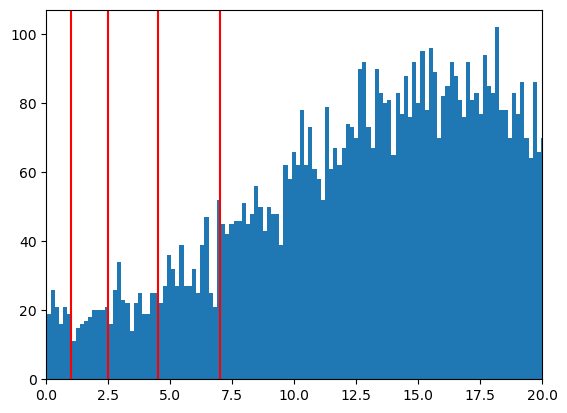

In [42]:
#plt.figure(figsize=(9, 3))
#plt.plot(distances)
plt.hist(distances, bins = 400)
plt.xlim(0, 20)
plt.axvline(x = 1, color = 'r')
plt.axvline(x = 2.5, color = 'r')
#plt.axvline(x = 3.5, color = 'r')
plt.axvline(x = 4.5, color = 'r')
plt.axvline(x = 7, color = 'r')
plt.show()

In [43]:
props_mask_df

,label,centroid-0,centroid-1,centroid-2,axis_major_length,axis_minor_length,distances
0,1,12.835158,524.729234,2438.823138,31.006026,21.971085,6.339608
1,2,15.586522,534.051325,2275.718992,38.781849,29.573591,10.074638
2,3,12.820479,527.343740,2409.140263,36.283222,24.870844,7.264511
3,4,14.145276,540.387187,2375.543583,42.085352,24.898455,8.645436
4,5,11.049805,554.736249,2568.896059,26.509073,20.623236,4.549805
...,...,...,...,...,...,...,...
12858,12859,101.105116,406.385116,2720.864186,22.954118,6.624199,3.606374
12859,12860,101.857988,311.710059,2784.887574,10.818892,5.407231,5.354398
12860,12861,102.389381,275.522124,2789.646018,11.778484,4.432733,7.207066
12861,12862,103.528169,378.176056,2735.915493,12.958168,4.314202,6.027653


In [44]:
props_mask_df["distances"][0]
props_mask_df["label"][0]

1

In [45]:
nb_objects, range(10)
len(props_mask_df)

12863

In [46]:
labels_new1 = copy.deepcopy(labels_mask)
labels_new2 = copy.deepcopy(labels_mask)
labels_new3 = copy.deepcopy(labels_mask)
labels_new4 = copy.deepcopy(labels_mask)

In [149]:
np.sum(labels_mask)

585268128135

In [150]:
labels_new1[np.where(labels_mask == 1)] = 0

In [151]:
 np.sum(labels_new1)

585268118817

In [157]:
labels_new4.shape,index_label,dist

((110, 1948, 2861), 140, 6.795992775435141)

In [47]:
for i in range(len(props_mask_df)):
    
    if i % 1000 == 0:
        print(i)
    
    
    index_label = props_mask_df["label"][i]
    dist = props_mask_df["distances"][i]
    
    if dist < 1:
        labels_new1[np.where(labels_mask == index_label)] = 0
    
    if dist < 2.5:
        labels_new2[np.where(labels_mask == index_label)] = 0
    
    if dist < 4.5:
        labels_new3[np.where(labels_mask == index_label)] = 0
    
    if dist < 7:
        labels_new4[np.where(labels_mask == index_label)] = 0
        

0
1000
2000
3000
4000
5000
6000
7000
8000
9000
10000
11000
12000


In [28]:
labels_new1 = imread(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_1.tif")))
labels_new2 = imread(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_2.tif")))
labels_new3 = imread(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_3.tif")))
labels_new4 = imread(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_4.tif")))

In [29]:
viewer.add_image(labels_new1, name='labels_reduced_1')
viewer.add_image(labels_new2, name='labels_reduced_2')
viewer.add_image(labels_new3, name='labels_reduced_3')
viewer.add_image(labels_new4, name='labels_reduced_4')

<Image layer 'labels_reduced_4' at 0x52cc021c0>

In [56]:
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_1.tif")), labels_new1)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_2.tif")), labels_new2)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_3.tif")), labels_new3)
#imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_4.tif")), labels_new4)

/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_45317/2681503692.py:1: UserWarning: results/test_3D_erosion/3d-Right4-Stitching_C1_labelMask_1.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_1.tif")), labels_new1)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_45317/2681503692.py:2: UserWarning: results/test_3D_erosion/3d-Right4-Stitching_C1_labelMask_2.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_2.tif")), labels_new2)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_45317/2681503692.py:3: UserWarning: results/test_3D_erosion/3d-Right4-Stitching_C1_labelMask_3.tif is a low contrast image
  imsave(os.path.join(outDir, str(fileName.removesuffix('.czi') + "_C1_labelMask_3.tif")), labels_new3)
/var/folders/ld/7f_9j5n17vs69r90p179ws240000gp/T/ipykernel_45317/2681503692.py:4: UserWarning: results/test_3D_erosion/3d-Right4-Stitching_C1_

In [50]:
np.max(labels_new4)

12863

In [35]:
labels_new4_binary = labels_new4 > 0

In [44]:
#filled_holes = ndi.binary_fill_holes(thresholded, structure=np.ones((50, 50, 20))).astype(int)
width = 20
remove_holes = morphology.remove_small_holes(
    labels_new4_binary, 
    area_threshold=width ** 3
)

In [46]:
viewer.add_image(remove_holes, name='remove_holes')

<Image layer 'remove_holes [2]' at 0x59c277c10>

In [47]:
np.max(remove_holes)

True

In [56]:
chull = morphology.convex_hull_image(remove_holes)

In [57]:
viewer.add_image(remove_holes, name='remove_holes_convexHull')

<Image layer 'remove_holes_convexHull' at 0x3b3a611c0>

In [51]:
flooded = morphology.flood_fill(labels_new4, (0, 0, 0), 12900)

In [52]:
np.max(flooded)

12900

In [53]:
flooded_binary = flooded < 12900

In [55]:
viewer.add_image(flooded, name='flooded')

<Image layer 'flooded' at 0x5525ead00>

In [31]:
np.max(binary_sphere)

True

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')
ax.plot_trisurf(
    tmesh.vertices[:, 0], 
    tmesh.vertices[:, 1], 
    tmesh.vertices[:, 2],
    triangles=tmesh.faces, 
) 
plt.show()

In [ ]:
import trimesh
import numpy as np

sp = trimesh.creation.icosphere(radius=0.5,subdivisions=5)

nf = len(sp.faces)

n = np.arange(nf)

colors = trimesh.visual.interpolate(n,color_map='jet')
sp.visual.face_colors = [100,100,100,0]

for i, color in zip(n,colors):
	sp.visual.face_colors[i] = color
	#print(i)
	
#stacking cylinders to make a scalebar

z_minus = min(sp.vertices[:,2])
z_plus = max(sp.vertices[:,2])
H = abs(z_plus)+abs(z_minus)

n_cy =100  # number of cylinders  to stack
h= H/n_cy

cylinders = [trimesh.creation.cylinder(0.05,h,400,smooth=True) for i in range(n_cy)]
cyl_colors = trimesh.visual.interpolate(np.arange(n_cy),color_map='jet')

for i,c in enumerate(cylinders):
	c.vertices[:,2] += i*h -abs(z_minus)
	c.vertices[:,0] += 0.9
	c.visual.face_colors = cyl_colors[i]
	
scene = trimesh.Scene([sp,cylinders])

In [ ]:
#scene.show(smooth=False)

In [37]:
#filled_holes = ndi.binary_fill_holes(thresholded, structure=np.ones((50, 50, 20))).astype(int)
width = 20
remove_holes = morphology.remove_small_holes(
    thresholded, 
    area_threshold=width ** 3
)

In [38]:
viewer.add_image(remove_holes, name='holefilled')

<Image layer 'holefilled' at 0x4014b45e0>

In [21]:
np.max(dapi_c1), np.min(dapi_c1), np.power(2, 16)

(32997, 0, 65536)

In [ ]:
#### test how to segment the tissue    

In [24]:
import cv2 as cv

In [36]:
flooded = morphology.flood_fill(li_thresholded, (1, 1, 1), t)

In [37]:
np.max(flooded), np.min(flooded)

(40344, 0)

In [42]:
viewer.add_image(flooded, name='floodFill')

<Image layer 'floodFill [2]' at 0x8597e72b0>

In [27]:
flooded = flooded > 2

In [30]:
np.max(flooded)

False

In [43]:
viewer.add_image(flooded, name='floodFill')

<Image layer 'floodFill' at 0x8592f0a60>

In [39]:
#filled = ndi.binary_fill_holes(li_thresholded)

In [40]:
viewer.add_image(filled, name='filled')

<Image layer 'filled' at 0x6262c0520>

In [57]:
viewer.add_image(remove_holes, name='remove_holes')

<Image layer 'remove_holes' at 0x648af7130>

In [ ]:
viewer.add_image(filled_holes, name='filled_v2')

In [ ]:
### code from ChatGPT
import os
import numpy as np
from scipy import ndimage as ndi
from skimage import filters, morphology, measure, exposure, segmentation, feature, util
from skimage.filters import threshold_local
from skimage.morphology import ball, remove_small_objects, remove_small_holes
from skimage.segmentation import watershed
from skimage.measure import label
import tifffile as tiff
import matplotlib.pyplot as plt


def load_volume(path):
    """
    Loads a 3D volume. Supports .tif/.tiff stacks or .npy arrays.
    Returns a float32 numpy array with shape (Z, Y, X).
    """
    ext = os.path.splitext(path)[1].lower()
    if ext in [".tif", ".tiff"]:
        vol = tiff.imread(path)
    elif ext == ".npy":
        vol = np.load(path)
    else:
        raise ValueError(f"Unsupported file extension: {ext}")
    vol = np.asarray(vol, dtype=np.float32)
    # If multi-channel, pick the DAPI channel here, e.g., vol = vol[:, :, :, dapi_idx]
    if vol.ndim != 3:
        raise ValueError(f"Expected 3D volume (Z, Y, X). Got shape {vol.shape}")
    return vol


def normalize_volume(vol, clip_percentile=(1, 99)):
    """
    Percentile clipping + rescale to [0, 1].
    """
    p1, p99 = np.percentile(vol, clip_percentile)
    vol = np.clip(vol, p1, p99)
    vol = (vol - vol.min()) / max(1e-8, (vol.max() - vol.min()))
    return vol.astype(np.float32)


def denoise_volume(vol, sigma_xy=1.0, sigma_z=1.0):
    """
    Anisotropic Gaussian denoise. You can tune sigmas based on voxel spacing.
    """
    sigma = (sigma_z, sigma_xy, sigma_xy)
    vol_smooth = ndi.gaussian_filter(vol, sigma=sigma)
    return vol_smooth.astype(np.float32)


def nuclei_segmentation(
    vol_norm,
    block_size_xy=51,
    block_size_z=9,
    offset=0.0,
    min_obj_size=200,
    hole_area_px=64,
    closing_radius=1,
    watershed_split=True,
    min_peak_distance=3
):
    """
    Segment nuclei in 3D using local thresholding + morphology, optionally watershed.
    - block_size_* should be odd integers, tuned to nucleus size and anisotropy.
    """
    z, y, x = vol_norm.shape

    # Local thresholding in 3D:
    # Do per-slice adaptive thresholding to respect anisotropy and speed
    bin_stack = np.zeros_like(vol_norm, dtype=bool)
    for iz in range(z):
        # Local adaptive threshold on each Z slice
        # Use odd block size; ensure within image bounds
        bxy = max(3, block_size_xy | 1)  # make odd
        th2d = threshold_local(vol_norm[iz], block_size=bxy, offset=offset, method='gaussian')
        bin_stack[iz] = vol_norm[iz] > th2d

    # Optional mild smoothing of binary along Z by majority vote
    # 3D morphological closing to fill tiny gaps
    if closing_radius > 0:
        selem = ball(closing_radius)
        bin_stack = morphology.closing(bin_stack, selem)

    # Clean small specks and fill small holes
    bin_stack = remove_small_objects(bin_stack, min_size=int(min_obj_size))
    bin_stack = remove_small_holes(bin_stack, area_threshold=int(hole_area_px))

    # Distance transform inside nuclei
    distance = ndi.distance_transform_edt(bin_stack)

    if watershed_split:
        # Find local maxima as seeds
        # Use peak_local_max in 3D; construct markers
        coords = feature.peak_local_max(
            distance,
            footprint=np.ones((3, 3, 3), dtype=bool),
            labels=bin_stack,
            min_distance=int(min_peak_distance)
        )
        markers = np.zeros_like(distance, dtype=int)
        for i, (zz, yy, xx) in enumerate(coords, start=1):
            markers[zz, yy, xx] = i

        # Watershed on negative distance to split touching nuclei
        labels_ws = watershed(-distance, markers, mask=bin_stack)
        # Remove tiny over-segmented fragments
        labels_ws = morphology.remove_small_objects(labels_ws, min_size=int(min_obj_size))
        nuclei_labels = labels_ws.astype(np.int32)
        nuclei_mask = nuclei_labels > 0
    else:
        nuclei_mask = bin_stack
        nuclei_labels = label(nuclei_mask, connectivity=1).astype(np.int32)

    return nuclei_mask, nuclei_labels, distance


def make_tissue_mask_from_nuclei(
    nuclei_mask,
    dilate_radius=5,
    closing_radius=7,
    fill_holes_3d=True,
    min_tissue_volume=5000
):
    """
    Heuristic tissue mask: dilate nuclei and close to approximate overall tissue.
    For dense DAPI labeling, this often outlines tissue regions well.
    """
    if dilate_radius > 0:
        nuclei_expanded = morphology.dilation(nuclei_mask, ball(int(dilate_radius)))
    else:
        nuclei_expanded = nuclei_mask

    if closing_radius > 0:
        tissue_mask = morphology.closing(nuclei_expanded, ball(int(closing_radius)))
    else:
        tissue_mask = nuclei_expanded

    if fill_holes_3d:
        tissue_mask = morphology.binary_closing(tissue_mask, ball(1))
        tissue_mask = remove_small_holes(tissue_mask, area_threshold=1000)

    tissue_mask = remove_small_objects(tissue_mask, min_size=int(min_tissue_volume))
    return tissue_mask.astype(bool)


def save_results(out_dir, nuclei_mask, nuclei_labels, tissue_mask):
    os.makedirs(out_dir, exist_ok=True)
    tiff.imwrite(os.path.join(out_dir, "nuclei_mask.tif"), nuclei_mask.astype(np.uint8) * 255)
    tiff.imwrite(os.path.join(out_dir, "nuclei_labels.tif"), nuclei_labels.astype(np.uint16))
    tiff.imwrite(os.path.join(out_dir, "tissue_mask.tif"), tissue_mask.astype(np.uint8) * 255)
    print(f"Saved to: {out_dir}")


def quick_qc_slices(vol, nuclei_mask, nuclei_labels, tissue_mask, z_slices=(0,)):
    """
    Quick visualization for a few Z slices.
    """
    z_slices = [z for z in z_slices if 0 <= z < vol.shape[0]]
    if not z_slices:
        z_slices = [vol.shape[0] // 2]

    for z in z_slices:
        fig, axs = plt.subplots(1, 4, figsize=(16, 4))
        axs[0].imshow(vol[z], cmap='gray')
        axs[0].set_title(f"Raw z={z}")
        axs[1].imshow(nuclei_mask[z], cmap='magma')
        axs[1].set_title("Nuclei mask")
        axs[2].imshow(nuclei_labels[z], cmap='tab20')
        axs[2].set_title("Nuclei labels")
        axs[3].imshow(tissue_mask[z], cmap='Greens')
        axs[3].set_title("Tissue mask")
        for ax in axs:
            ax.axis('off')
        plt.tight_layout()
    plt.show()


def main(
    input_path,
    output_dir="seg_out",
    sigma_xy=1.0,
    sigma_z=1.0,
    block_size_xy=51,
    block_size_z=9,  # not used in per-slice local threshold, kept for potential 3D methods
    offset=-0.05,
    min_obj_size=200,
    hole_area_px=64,
    closing_radius=1,
    watershed_split=True,
    min_peak_distance=4,
    tissue_dilate_radius=5,
    tissue_closing_radius=7,
    min_tissue_volume=5000,
    show_qc=True
):
    # Load
    vol = load_volume(input_path)

    # Normalize and denoise
    vol_norm = normalize_volume(vol, clip_percentile=(1, 99))
    vol_smooth = denoise_volume(vol_norm, sigma_xy=sigma_xy, sigma_z=sigma_z)

    # Segment nuclei
    nuclei_mask, nuclei_labels, _ = nuclei_segmentation(
        vol_smooth,
        block_size_xy=block_size_xy,
        block_size_z=block_size_z,
        offset=offset,
        min_obj_size=min_obj_size,
        hole_area_px=hole_area_px,
        closing_radius=closing_radius,
        watershed_split=watershed_split,
        min_peak_distance=min_peak_distance
    )

    # Build tissue mask from nuclei
    tissue_mask = make_tissue_mask_from_nuclei(
        nuclei_mask,
        dilate_radius=tissue_dilate_radius,
        closing_radius=tissue_closing_radius,
        fill_holes_3d=True,
        min_tissue_volume=min_tissue_volume
    )

    # Save outputs
    save_results(output_dir, nuclei_mask, nuclei_labels, tissue_mask)

    # Optional quick QC plots for a few slices
    if show_qc:
        zc = vol.shape[0] // 2
        quick_qc_slices(vol_norm, nuclei_mask, nuclei_labels, tissue_mask, z_slices=[zc, max(0, zc - 10), min(vol.shape[0]-1, zc + 10)])


if __name__ == "__main__":
    # Example usage:
    # python script.py  (then modify paths here)
    INPUT_PATH = "dapi_volume.tif"  # or "dapi_volume.npy"
    OUTPUT_DIR = "seg_out"

    # If running as a script, adjust parameters here or integrate argparse
    if not os.path.exists(INPUT_PATH):
        print(f"Please set INPUT_PATH to your 3D DAPI stack (TIFF or NPY). Current: {INPUT_PATH}")
    else:
        main(
            input_path=INPUT_PATH,
            output_dir=OUTPUT_DIR,
            sigma_xy=1.0,
            sigma_z=1.0,
            block_size_xy=51,
            block_size_z=9,
            offset=-0.05,           # negative offset makes threshold slightly lower (more sensitive)
            min_obj_size=200,       # voxel count threshold; tune to smallest nucleus size
            hole_area_px=64,
            closing_radius=1,
            watershed_split=True,
            min_peak_distance=4,
            tissue_dilate_radius=6, # increase for sparser nuclei to pad tissue
            tissue_closing_radius=8,
            min_tissue_volume=5000,
            show_qc=True
        )